# Часть 1

1. Выберите одну любую из задач, рассмотренных на [лекции](https://colab.research.google.com/drive/1B7Np_7y002NLiuNkriq6a6MchQL4Fw7p?usp=sharing) (локализация, сегментация, перенос стиля, генерация).
2. Подберите на kaggle датасет, подходящий для решения этой задачи.
  - Вариант 1: если данные обладают необходимой разметкой, то повторите пайплайн из блокнота с примером на своих данных.
  - Вариант 2: если данные не обладают необходимой разметкой, то используйте модель, которую дообучали в примере, но без дообучения.
3. Оцените и прокомментируйте результат.

In [1]:
# загрузка датасета
import kagglehub


path = kagglehub.dataset_download("georgemartvel/catflw")


print("Path to dataset files:", path)



100%|██████████| 1.35G/1.35G [00:25<00:00, 56.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2


In [2]:
import os


file_path = "/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/labels"
print(os.listdir(file_path))


['00000333_012.json', '00000033_011.json', '00000351_003.json', '00000371_011.json', '00000392_013.json', '00000335_027.json', 'CAT_01_00000107_001.json', '00000315_013.json', '00000383_020.json', '00000051_005.json', '00000378_010.json', '00000009_015.json', 'CAT_01_00000142_027.json', 'CAT_01_00000131_010.json', '00000343_020.json', 'CAT_01_00000174_015.json', '00000016_013.json', '00000009_022.json', '00000075_027.json', 'CAT_01_00000173_022.json', '00000402_025.json', 'CAT_01_00000110_029.json', '00000346_013.json', 'CAT_01_00000149_010.json', '00000001_012.json', 'CAT_01_00000134_015.json', '00000345_014.json', '00000447_011.json', 'CAT_01_00000169_026.json', 'CAT_01_00000182_020.json', '00000454_015.json', '00000096_003.json', '00000395_016.json', '00000355_010.json', '00000006_022.json', '00000059_002.json', '00000448_027.json', '00000031_028.json', '00000046_014.json', 'CAT_01_00000164_026.json', '00000371_006.json', 'CAT_01_00000175_005.json', '00000037_002.json', '00000365_01

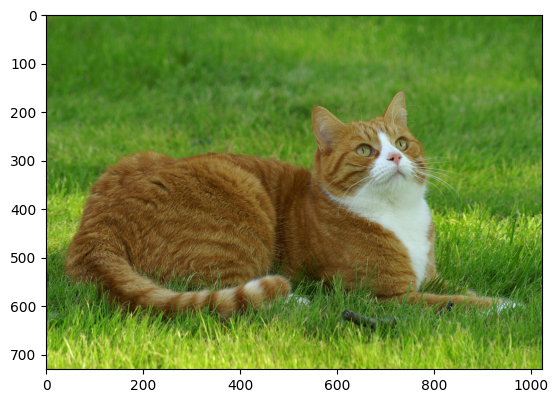

In [3]:
# проверяем что датасет загрузился. например, можем посмотреть какую-нибудь кошечку из датасета

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/images/CAT_01_00000163_014.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()


# Подготовка данных
Конвертируем JSON разметку датасета в удобный формат

In [ ]:
import os
import pandas as pd
import json

def parse_annotations_from_folder(labels_dir):
    rows = []
    for filename in os.listdir(labels_dir):
        if filename.endswith(".json"):
            json_path = os.path.join(labels_dir, filename)
            with open(json_path, 'r') as file:
                data = json.load(file)

            # Обработка данных для каждого файла
            img_path = filename.replace(".json", ".png")  # предполагается, что изображения имеют такие же имена
            bbox = data['bounding_boxes']  # Получаем bounding box
            labels = data['labels']  # Получаем метки

            for label in labels:
                rows.append({
                    'img_path': img_path,
                    'xmin': bbox[0],  # x1 из bounding box
                    'ymin': bbox[1],  # y1 из bounding box
                    'xmax': bbox[2],  # x2 из bounding box
                    'ymax': bbox[3],  # y2 из bounding box
                    'label_x': label[0],  # Координата x для каждой метки
                    'label_y': label[1],  # Координата y для каждой метки
                })

    return pd.DataFrame(rows)

labels_dir = '/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/labels'
df = parse_annotations_from_folder(labels_dir)
print(df.head(20))


            img_path   xmin  ymin   xmax   ymax  label_x  label_y
0   00000333_012.png  202.0  20.0  325.0  139.0  263.187  121.379
1   00000333_012.png  202.0  20.0  325.0  139.0  280.761   88.326
2   00000333_012.png  202.0  20.0  325.0  139.0  263.527  126.665
3   00000333_012.png  202.0  20.0  325.0  139.0  245.971   91.149
4   00000333_012.png  202.0  20.0  325.0  139.0  237.429   86.878
5   00000333_012.png  202.0  20.0  325.0  139.0  252.748   92.925
6   00000333_012.png  202.0  20.0  325.0  139.0  245.785   84.145
7   00000333_012.png  202.0  20.0  325.0  139.0  246.023   96.680
8   00000333_012.png  202.0  20.0  325.0  139.0  287.865   82.896
9   00000333_012.png  202.0  20.0  325.0  139.0  273.071   91.602
10  00000333_012.png  202.0  20.0  325.0  139.0  279.927   80.174
11  00000333_012.png  202.0  20.0  325.0  139.0  280.476   92.200
12  00000333_012.png  202.0  20.0  325.0  139.0  259.795  109.985
13  00000333_012.png  202.0  20.0  325.0  139.0  267.441  110.034
14  000003

## Neural Style Transfer

## Задача


Объединить две картинки, используя одну из них в качестве фильтра.

In [ ]:
!pip install torch torchvision

In [ ]:
!git clone https://github.com/parth1620/Project-NST.git

Cloning into 'Project-NST'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 19 (delta 2), reused 1 (delta 1), pack-reused 16 (from 1)
Receiving objects: 100% (19/19), 3.30 MiB | 5.85 MiB/s, done.
Resolving deltas: 100% (2/2), done.


## Загрузка VGG19

Для решения задачи воспользуемся параметрами из предобученной VGG19.

In [ ]:
import torch
from torchvision import models

vgg = models.vgg19(pretrained=True)
print(vgg)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:07<00:00, 77.3MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
vgg = vgg.features
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [ ]:
for parameters in vgg.parameters():
  parameters.requires_grad_(False)

In [ ]:
dev = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(dev)

cuda


In [ ]:
vgg.to(dev)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [ ]:
vgg.to(dev)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

## Предобработка изображений

Torchvision models page : https://pytorch.org/docs/stable/torchvision/models.html

In [ ]:
from PIL import Image
from torchvision import transforms as T

def preprocess(img_path, max_size=500):
  image = Image.open(img_path).convert("RGB")
  if max(image.size) > max_size:
    size = max_size
  else:
    size = max(image.size)

  img_transforms = T.Compose([
      T.Resize(size),
      T.ToTensor(),
      T.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
  ])
  image = img_transforms(image)
  image = image.unsqueeze(0) # (3, 224, 224) -> (1, 3, 224, 224)

  return image

In [ ]:
content_preprocess = preprocess("/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/images/00000333_012.png")
style_preprocess = preprocess("/content/wallpaper.jpg")

content_preprocess = content_preprocess.to(dev)
style_preprocess = style_preprocess.to(dev)

print(f"Content shape {content_preprocess.shape}")
print(f"Style shape {style_preprocess.shape}")

Content shape torch.Size([1, 3, 500, 889])
Style shape torch.Size([1, 3, 500, 892])


## Преобразование вектора в картинку

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def deprocess(tensor):
  image = tensor.to("cpu").clone()
  image = image.numpy()
  image = image.squeeze(0) # (1, 3, 224, 224) -> (3, 224, 224)
  image = image.transpose(1, 2, 0) # (3, 224, 224) -> (224, 224, 3)
  image = image * np.array([0.485, 0.456, 0.406]) + np.array([0.229, 0.224, 0.225])
  image = image.clip(0,1)

  return image


In [ ]:
content_deproc = deprocess(content_preprocess)
style_deproc = deprocess(style_preprocess)

print(f"Deprocess content: {content_deproc.shape}")
print(f"Deprocess style: {style_deproc.shape}")

Deprocess content: (500, 889, 3)
Deprocess style: (500, 892, 3)


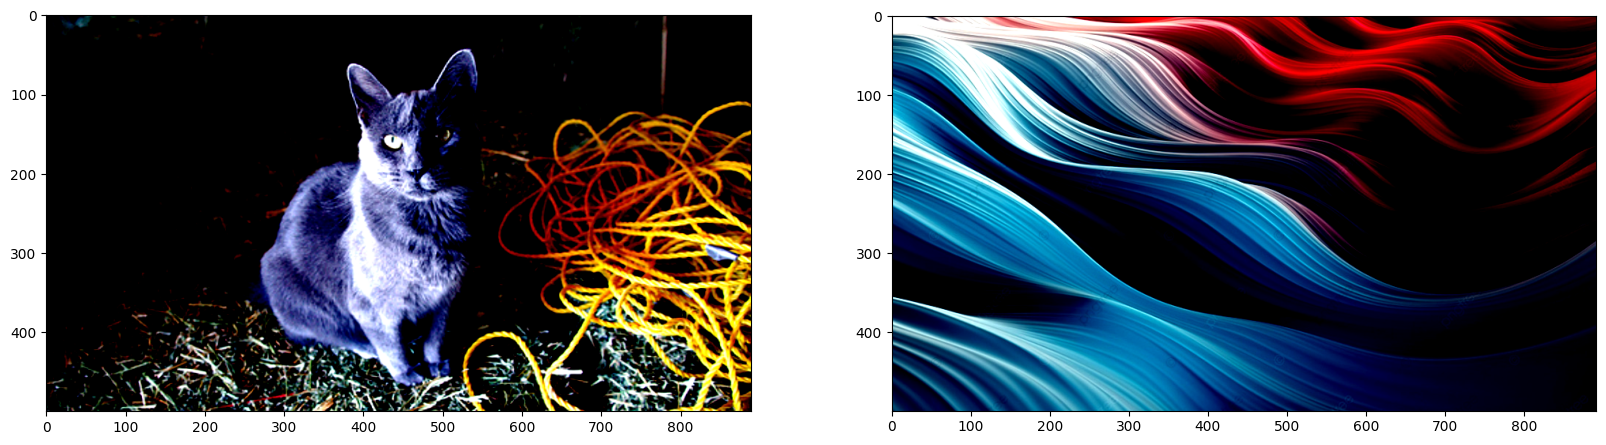

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,10))
ax1.imshow(content_deproc)
ax2.imshow(style_deproc);

## Извлечение признаков из картинки и стиля, построение матрицы Грама

In [ ]:
def get_features(image, model):
  layers = {
      "0": "conv1_1",  # see representaion.png
      "5": "conv2_1",
      "10": "conv3_1",
      "19": "conv4_1",
      "21": "conv4_2", #content_feature
      "28": "conv5_1"
  }

  x = image
  Features = {}
  for name, layer in model._modules.items():
    x = layer(x)
    if name in layers:
      Features[layers[name]] = x

  return Features

In [ ]:
content_features = get_features(content_preprocess, vgg)
style_features = get_features(style_preprocess, vgg)

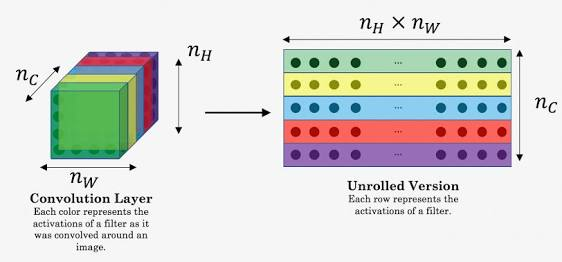

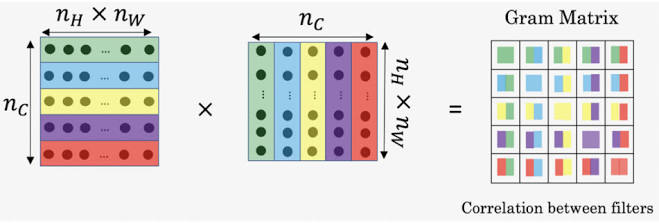

In [ ]:
def gram_matrix(tensor):
  b, c, h, w = tensor.size()
  tensor = tensor.view(c, h*w)
  gram = torch.mm(tensor, tensor.t())
  return gram

In [ ]:
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

## Создание функций потерь для картинки и стиля

In [ ]:
def content_loss(target_conv4_2, content_conv4_2):
  loss = torch.mean((target_conv4_2-content_conv4_2)**2)
  return loss

In [ ]:
style_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.75,
    "conv4_1": 0.75,
    "conv5_1": 0.75
}

In [ ]:
def style_loss(style_weights, target_fs, style_grams):
  loss = 0
  for layer in style_weights:
    target_feature = target_fs[layer]
    target_gram = gram_matrix(target_feature)
    style_gram = style_grams[layer]
    b, c, h, w = target_feature.shape
    layer_loss = style_weights[layer]*torch.mean((target_gram-style_gram)**2)
    loss += layer_loss/(c*h*w)

  return loss

In [ ]:
target = content_preprocess.clone().requires_grad_(True).to(dev)
target_f = get_features(target,vgg)
print(f"Content loss: {content_loss(target_f['conv4_2'], content_features['conv4_2'])}")
print(f"Style loss: {style_loss(style_weights, target_f,style_grams)}")

Content loss: 0.0
Style loss: 1437.0850830078125


## Обучение модели

In [ ]:
from torch import optim

optimizer = optim.Adam([target],lr=0.003)

alpha = 1.0
beta = 1e5
epochs = 4000
show_every = 500

In [ ]:
def total_loss(c_loss, s_loss, alpha, beta):
  loss = alpha*c_loss + beta*s_loss
  return loss

In [ ]:
results = []

for i in range(epochs):
  target_f = get_features(target,vgg)
  c_loss = content_loss(target_f["conv4_2"], content_features["conv4_2"])
  s_loss = style_loss(style_weights, target_f, style_grams)
  t_loss = total_loss(c_loss,s_loss, alpha, beta)

  optimizer.zero_grad()
  t_loss.backward()
  optimizer.step()

  if i % show_every == 0:
    print(f"Total loss at Epoch {i}: {t_loss}")
    results.append(deprocess(target.detach()))

Total loss at Epoch 0: 143708512.0
Total loss at Epoch 500: 13788130.0
Total loss at Epoch 1000: 2582604.5
Total loss at Epoch 1500: 1187115.0
Total loss at Epoch 2000: 699580.5
Total loss at Epoch 2500: 457479.8125
Total loss at Epoch 3000: 313641.09375
Total loss at Epoch 3500: 220893.40625


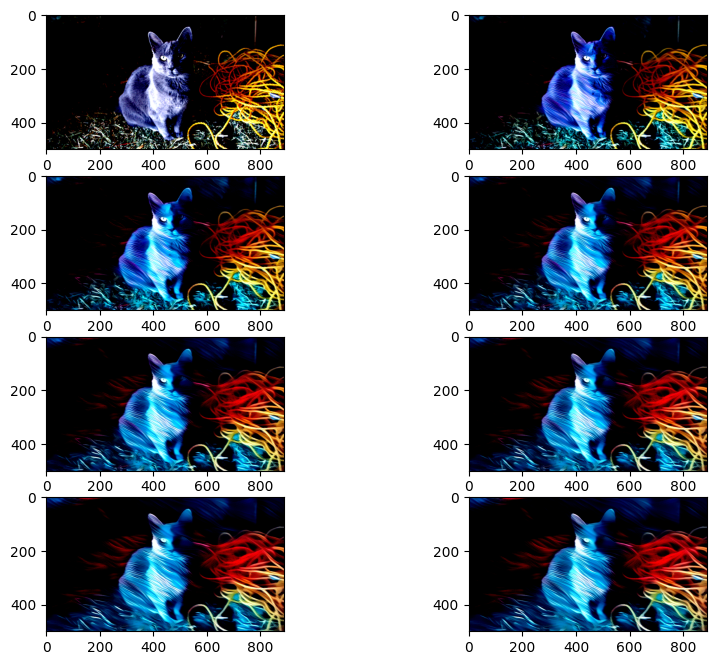

In [ ]:
plt.figure(figsize=(10,8))
for i,_ in enumerate(results):
  plt.subplot(4,2, i+1)
  plt.imshow(results[i])
plt.show()

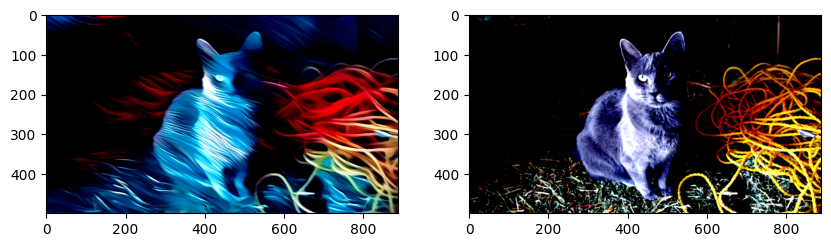

In [ ]:
target_copy = deprocess(target.detach())
content_copy = deprocess(content_preprocess)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(target_copy)
ax2.imshow(content_copy);

Вывод: Хороший результат, получилась красивая картинка, и при этом стиль наложился в соответсвии с картинкой. Провода, которые были на картинке рядом с кошкой, сделали красивый эффект в середине картинки.

# Часть 2

1. Выберите еще одну из рассмотренных в лекции задач (не совпадающую с первой).
2. Если ваши данные обладают разметкой, необходимой для новой задачи, продолжите работу с ними. Если нет, найдите другой датасет, в котором она будет. Можно взять какой-нибудь стандартный в PyTorch, но такой, который не встречался ни в одном из примеров с лекции. В этом задании обязательно нужно найти датасет с разметкой.
3. Повторите пайплайн из примера.
4. Постарайтесь улучшить качество результата (если классификация - точность выше 90%, во всех остальных - максимально понизить лосс). Это можно сделать за счет настройки гиперпараметров. Можно (опционально и в зависимости от задачи) также поменять гиперпараметры в слоях нейронных сетей и/или порядок слоев и/или их количество.

## Локализация

In [ ]:
# установка необходимых библиотек
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-4hrcomul
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-4hrcomul
  Resolved https://github.com/albumentations-team/albumentations to commit eb8d404475d01a3ba4293c36911f01eda9c2fba5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Настройка гиперпараметров

In [ ]:
import pandas as pd
import json
import torch


csv_file = '/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/labels'
data_dir = '/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/images'

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 16
img_size = 140
lr = 0.001
epochs = 40
model_name = "efficientnet_b0"  # Альтернатива: resnet34


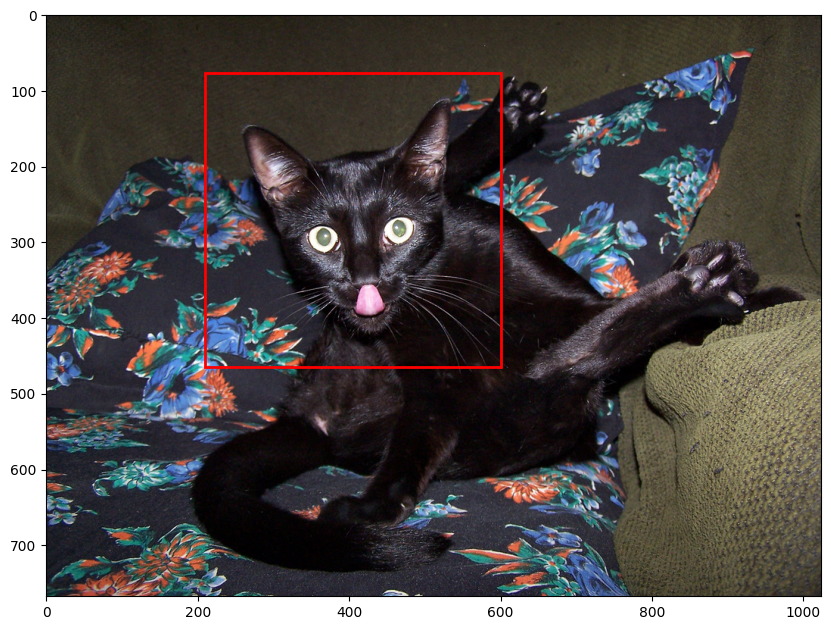

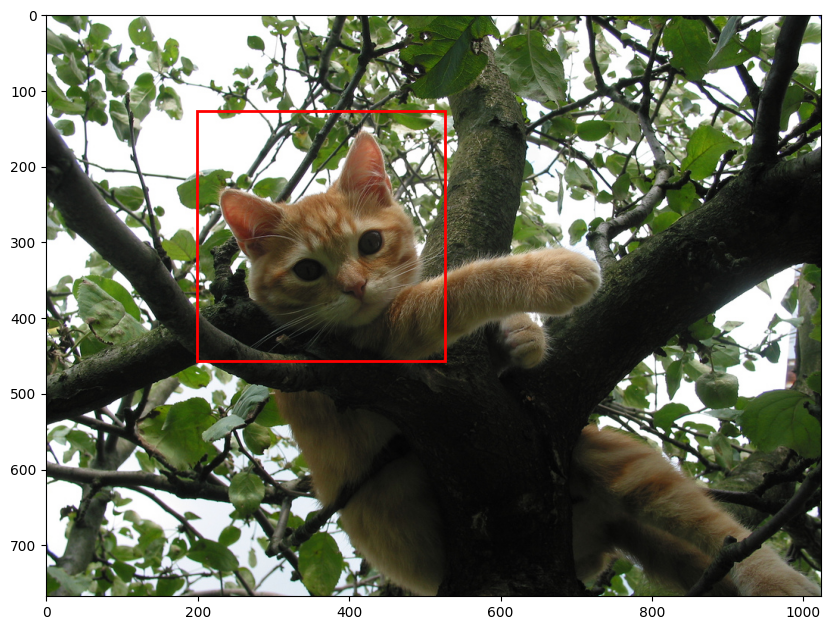

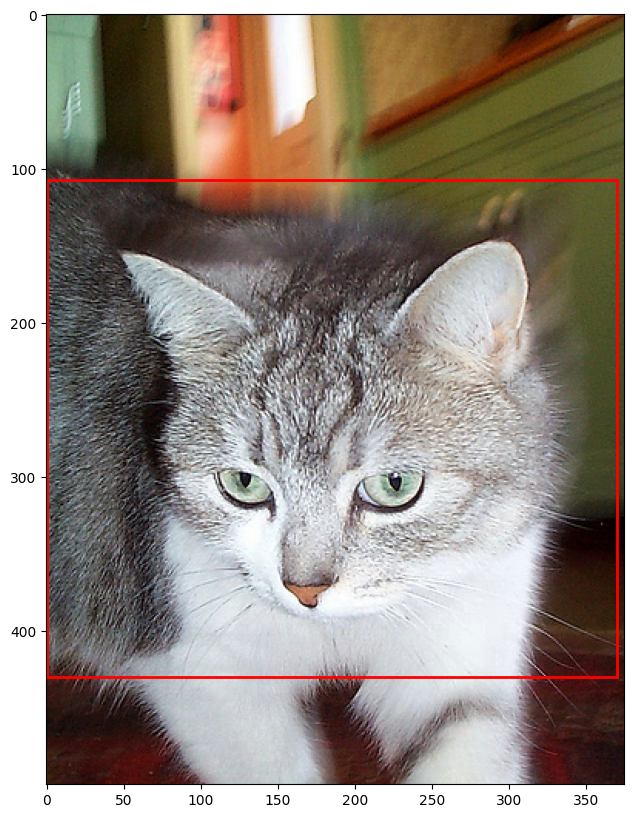

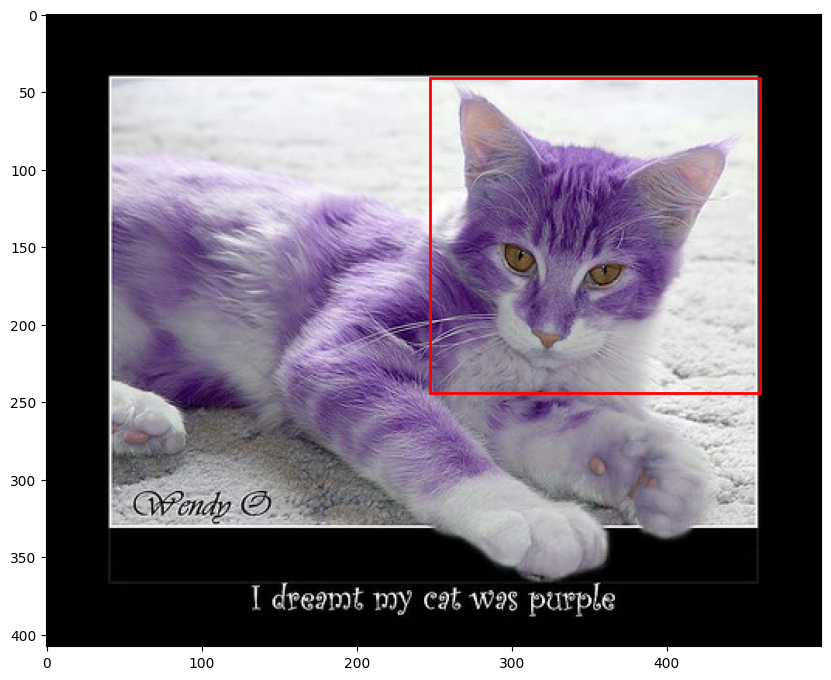

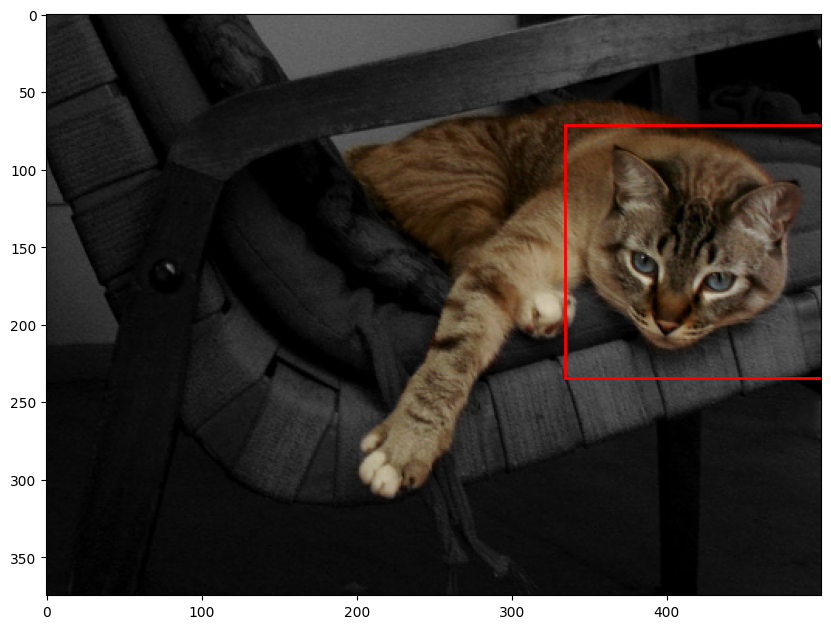

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Функция для отображения изображения с bounding box
def show_image_with_bbox(df, idx):
    img_path = '/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/images/' + df.iloc[idx]['img_path']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Преобразуем в RGB

    # Извлекаем координаты bounding box
    xmin = df.iloc[idx]['xmin']
    ymin = df.iloc[idx]['ymin']
    xmax = df.iloc[idx]['xmax']
    ymax = df.iloc[idx]['ymax']

    # Рисуем bounding box
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.show()


for i in range(5):
    show_image_with_bbox(df, i)


# Агументация данных
Настраиваем аугментации для изображений и рамок с учетом кошачьих лиц


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_augs = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20),
    A.Normalize(),
    ToTensorV2()
], bbox_params=A.BboxParams(format="pascal_voc"))

val_augs = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(),
    ToTensorV2()
], bbox_params=A.BboxParams(format="pascal_voc"))


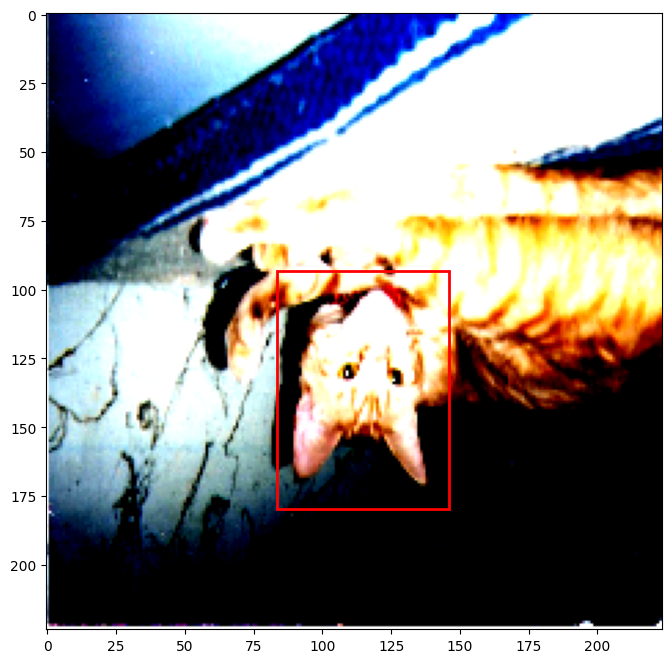

In [ ]:
# Проверяем, что агументация выполнена верно на примере рандомного котика
import cv2
import numpy as np
import matplotlib.pyplot as plt
from albumentations import Compose, Resize, HorizontalFlip, VerticalFlip, Rotate, Normalize
from albumentations.pytorch import ToTensorV2
from albumentations import BboxParams

# Параметры аугментации
img_size = 224
train_augs = Compose([
    Resize(img_size, img_size),
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.5),
    Rotate(limit=20),
    Normalize(),
    ToTensorV2()
], bbox_params=BboxParams(format="pascal_voc"))


image = cv2.imread('/root/.cache/kagglehub/datasets/georgemartvel/catflw/versions/2/CatFLW dataset/images/00000015_026.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Преобразуем в RGB формат для корректного отображения
bboxes = [[174.0, 68.0, 314.0, 201.0, 0]]

# Применение аугментаций
augmented = train_augs(image=image, bboxes=bboxes)

augmented_image = augmented['image']
augmented_bboxes = augmented['bboxes']


# Визуализация изображения с bounding box
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(augmented_image.permute(1, 2, 0))  # преобразование Tensor в изображение

# Извлекаем только координаты для прямоугольников
for bbox in augmented_bboxes:
    xmin, ymin, xmax, ymax, _ = bbox  # Игнорируем метку класса
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

plt.show()


# Создание датасета

In [ ]:
import torch
from torch.utils.data import Dataset

class ObjectLocalizationDataset(Dataset):
    def __init__(self, dataframe, augmentations=None):
        self.dataframe = dataframe
        self.augmentations = augmentations

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = cv2.imread(f"{data_dir}/{row['img_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bbox = [row['xmin'], row['ymin'], row['xmax'], row['ymax']]
        if self.augmentations:
            augmented = self.augmentations(image=image, bboxes=[bbox])
            image, bbox = augmented['image'], augmented['bboxes'][0]

        return image, torch.tensor(bbox, dtype=torch.float32)

trainset = ObjectLocalizationDataset(train_df, train_augs)
valset = ObjectLocalizationDataset(val_df, val_augs)


NameError: name 'train_df' is not defined

Вывод: получилось локализовать кошку и выделить голову.